## Convert MRDH demand data (from activity-based model used in XCARCITY project) to MaaSSim input data

### Set-up

In [1]:
import pandas as pd
import osmnx as ox
import networkx as nx
import os
from link_demand_to_osm import *
from preprocess_utils import *

In [3]:
# input parameters
study_area = "MRDH"
year = 2025
month = 4
day = 1
min_trip_dist = 1000 # meter
# sample_size = 500 # before filtering in this case

In [4]:
# Preprocess
date = {'year': year, 'month': month, 'day': day}
nw_type_extensions = {'drive': '', 'bike': '_bike', 'walk': '_walk'}
skim_available = {'drive': True, 'bike': True}
presaved_zones = False

### Sample the demand data
First, we download the data, compute some additional statistics and select trips (possibly based on a filter)

In [5]:
trips = pd.read_csv('50PercentTrips.csv') #nrows=sample_size
pax = pd.read_csv('50PercentPersons.csv').sort_values(by='person_id') #.head(sample_size)
trips

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y
0,5513,16,shopping,bike,9,22,82350.546875,458161.93750,87515.648438,457049.25000
1,11201,34,eatout,ebike,8,39,82362.250000,458146.87500,80806.382812,455101.43750
2,15353,46,shopping,ebike,9,5,82330.109375,458188.06250,81656.328125,455156.25000
3,24473,74,othdiscr,ebike,8,49,82410.195312,458051.03125,83403.460938,455115.00000
4,30489,92,work,bike,7,41,82330.109375,458188.06250,84138.812500,450752.40625
...,...,...,...,...,...,...,...,...,...,...
496436,841180521,2564574,school,bike,7,34,68856.296875,445485.00000,71193.179688,446046.71875
496437,841181569,2564577,work,car,7,51,68757.085938,445328.21875,91031.039062,456781.43750
496438,841183121,2564582,othmaint,car,8,40,69008.429688,445345.62500,83888.335938,445593.53125
496439,841183801,2564584,school,cp,8,2,68870.312500,445534.50000,75064.593750,445768.90625


In [6]:
# Determine eucledian distance and filter based on distance, also filter adults
trips['eucledian_dist'] = trips.apply(lambda row: eucledian_distance(row['origin_coordinate_x'], row['origin_coordinate_y'], row['destination_coordinate_x'], row['destination_coordinate_y']), axis=1)
trips = trips[trips['eucledian_dist'] > min_trip_dist].copy()
pax = pax[pax['person_id'].isin(trips['person_id'])].copy()
pax = pax[pax['age'] >= 18].copy()
trips = trips[trips['person_id'].isin(pax['person_id'])].copy()
processed_demand = pd.DataFrame(index=trips.index)
processed_demand['person_id'] = trips['person_id'].copy()
processed_demand[['purpose', 'activity_mode_model']] = trips[['purpose', 'trip_mode']].copy()
trips

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y,eucledian_dist
0,5513,16,shopping,bike,9,22,82350.546875,458161.93750,87515.648438,457049.25000,5283.592303
1,11201,34,eatout,ebike,8,39,82362.250000,458146.87500,80806.382812,455101.43750,3419.855592
2,15353,46,shopping,ebike,9,5,82330.109375,458188.06250,81656.328125,455156.25000,3105.779807
3,24473,74,othdiscr,ebike,8,49,82410.195312,458051.03125,83403.460938,455115.00000,3099.492878
4,30489,92,work,bike,7,41,82330.109375,458188.06250,84138.812500,450752.40625,7652.476126
...,...,...,...,...,...,...,...,...,...,...,...
496434,841176977,2564563,work,bike,7,40,68616.046875,443964.18750,69728.328125,443025.96875,1455.137108
496435,841179929,2564572,work,bike,8,27,69059.187500,445601.75000,76936.101562,443522.12500,8146.816267
496437,841181569,2564577,work,car,7,51,68757.085938,445328.21875,91031.039062,456781.43750,25046.061717
496438,841183121,2564582,othmaint,car,8,40,69008.429688,445345.62500,83888.335938,445593.53125,14881.971224


In [7]:
# Convert trip coordinates in RD New system to WGS84 coordinates and compute some general trip statistics
processed_demand['origin_wgs84'] = trips.apply(lambda row: coordinate_conversion(row.origin_coordinate_x, row.origin_coordinate_y), axis=1)
processed_demand['dest_wgs84'] = trips.apply(lambda row: coordinate_conversion(row.destination_coordinate_x, row.destination_coordinate_y), axis=1)
processed_demand['eucl_dist'] = trips['eucledian_dist']
processed_demand['treq'] = trips.apply(lambda row: determine_treq(row, date=dict()), axis=1) # determine the required departure time for the trip

### Load network(s)
First, we load the network from OpenStreetMap and finding the corresponding OSM node for each request

In [9]:
# First, we download the network data (incl. skim matrices) for each type (drive, bike, walk), which has already been downloaded from OSM and saved
network_types = determine_preprocessed_network_types(study_area, nw_type_extensions)
graphs=dict()
for network_type in network_types:
    skim_type = skim_available[network_type]
    print(f"Loading {network_type} network data")
    extension = nw_type_extensions[network_type]
    G, skims = load_fleetpy_network(study_area, network_type, return_skim=skim_type, presaved_zones=presaved_zones)
    # df = pd.DataFrame()

    # 1. Extract coordinates as numpy arrays
    x_origins = processed_demand['origin_wgs84'].apply(lambda x: x[1]).to_numpy()
    y_origins = processed_demand['origin_wgs84'].apply(lambda x: x[0]).to_numpy()
    x_dest = processed_demand['dest_wgs84'].apply(lambda x: x[1]).to_numpy()
    y_dest = processed_demand['dest_wgs84'].apply(lambda x: x[0]).to_numpy()

    # 2. Use osmnx's vectorized nearest_nodes (fast!)
    origin_ids = ox.distance.nearest_nodes(G, X=x_origins, Y=y_origins)
    dest_ids = ox.distance.nearest_nodes(G, X=x_dest, Y=y_dest)

    # 3. Create new DataFrame
    df = pd.DataFrame({
        f'origin_id{extension}': origin_ids,
        f'destination_id{extension}': dest_ids, 
    }, index=processed_demand.index)

    # 4. Travel times and distances
    if skims is not None:
        origin_ids = np.asarray(origin_ids, dtype=int)
        dest_ids = np.asarray(dest_ids, dtype=int)
        tt_vals = skims['tt'][origin_ids, dest_ids]
        dist_vals = skims['distance'][origin_ids, dest_ids]
        df[f'ttrav{extension}'] = tt_vals
        df[f'dist{extension}'] = dist_vals
    else:
        # fallback with loop only if necessary
        df[f'ttrav{extension}'] = [
            nx.shortest_path_length(G, o, d, weight="travel_time")
            for o, d in zip(origin_ids, dest_ids)
        ]

    # 5. Concatenate back to main df
    processed_demand = pd.concat([processed_demand, df], axis=1)
    graphs[network_type] = G.copy()
    
skims = None # remove from memory
G = None

Loading drive network data
Loading bike network data


In [10]:
processed_demand

,person_id,purpose,activity_mode_model,origin_wgs84,dest_wgs84,eucl_dist,treq,origin_id,destination_id,ttrav,dist,origin_id_bike,destination_id_bike,ttrav_bike,dist_bike
0,16,shopping,bike,"(52.106918931466005, 4.326727505881064)","(52.09757335668234, 4.402332605039179)",5283.592303,2025-04-01 09:22:20,44359,43823,599.304199,8751.430664,32264,31838,1558.04814,8655.823
1,34,eatout,ebike,"(52.10678510502127, 4.32690152160677)","(52.07921018221462, 4.304856898679823)",3419.855592,2025-04-01 08:39:47,44359,41669,373.169769,4588.945801,32264,30360,815.21298,4528.961
2,46,shopping,ebike,"(52.10715102648641, 4.326423652964237)","(52.0798159946642, 4.317242151280532)",3105.779807,2025-04-01 09:05:06,44359,41686,331.312805,4141.410156,32264,30484,730.57752,4058.764
3,74,othdiscr,ebike,"(52.10593007298513, 4.3276216901900115)","(52.07967393906055, 4.342734443747269)",3099.492878,2025-04-01 08:49:11,44308,41790,331.494720,4143.684082,32239,30446,659.12958,3661.831
4,92,work,bike,"(52.10715102648641, 4.326423652964237)","(52.04056241931939, 4.354365431851417)",7652.476126,2025-04-01 07:41:37,44359,34197,792.331787,13013.814453,32264,24996,1905.14142,10584.119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496434,2564563,work,bike,"(51.977359514646274, 4.129873190459639)","(51.969100125957254, 4.146292147798944)",1455.137108,2025-04-01 07:40:18,26928,26424,157.903152,1761.906006,20039,19716,267.13980,1484.110
496435,2564572,work,bike,"(51.99214410381971, 4.135911203980937)","(51.97461859496892, 4.251049314401504)",8146.816267,2025-04-01 08:27:34,55495,26627,552.368347,9566.925781,45256,19884,1721.81808,9565.656
496437,2564577,work,car,"(51.98963919068183, 4.131582463704532)","(52.09558398190582, 4.453679991209237)",25046.061717,2025-04-01 07:51:58,55482,55344,1661.532715,32227.933594,45245,44971,5131.92060,28510.670
496438,2564582,othmaint,car,"(51.98983459723029, 4.135236603196908)","(51.994167881892615, 4.351786983406339)",14881.971224,2025-04-01 08:40:04,55484,28894,1011.563171,17725.431641,45244,21362,3158.93016,17549.612


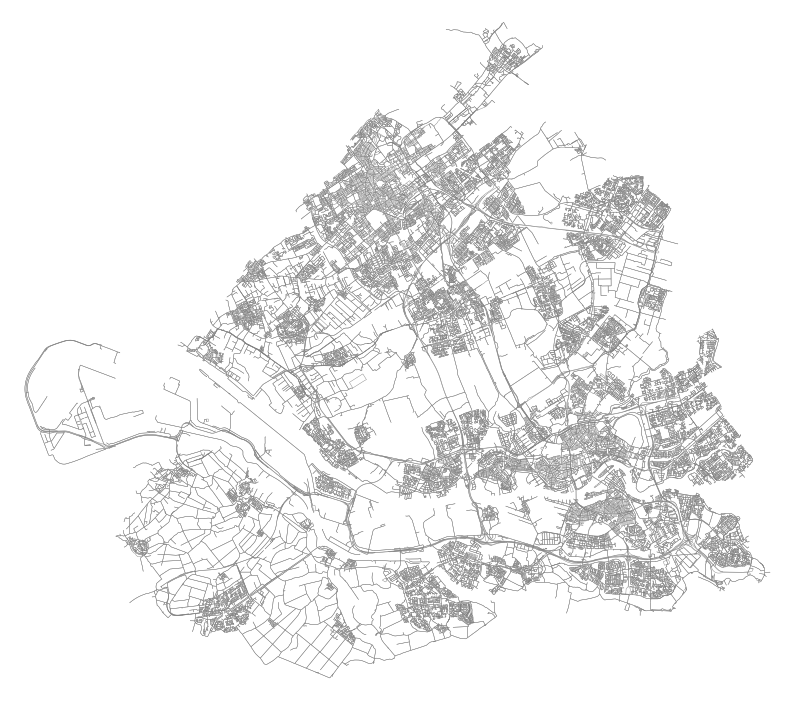

In [13]:
# Plot network
_ = ox.plot_graph(graphs['drive'], figsize=(10, 10), node_size=0, edge_linewidth=0.3,
                            show=False, close=False,
                            edge_color='grey', bgcolor='white')

Below, we establish passenger (not trip) data

In [ ]:
passengers = pax[['person_id', 'urbanized', 'driving_license', 'age', 'value_of_time']].copy()
passengers['sex'] = pax.apply(lambda row: "Male" if row.sex == 1 else "Female", axis=1)
passengers['bike_option'] = pax.apply(lambda row: True if row.has_bike + row.has_ebike > 0 else False, axis=1)
passengers['car_option'] = pax.apply(lambda row: True if row.has_car > 0 and row.driving_license > 0 else False, axis=1)
passengers = passengers.rename(columns={'value_of_time': 'VoT'})


### Save demand dataframes (requests and passengers)

In [15]:
# Output path
output_path = "output"

In [16]:
# Save person characterstics to csv
passengers = passengers[passengers['person_id'].isin(processed_demand['person_id'])]  # only keep id's of people who make a (filtered) trip (double check)
passengers = passengers.rename(columns={'person_id': 'pax_id'})
passengers.to_csv(os.path.join(output_path,'passengers.csv'), index=False)
passengers

,pax_id,urbanized,driving_license,age,VoT,age,sex,bike_option,car_option
49252,16,3,1,58,5.151567,58,Male,True,False
298284,34,3,1,69,16.260024,69,Male,True,True
198944,46,3,1,72,9.741094,72,Female,True,True
446718,74,3,1,71,30.748218,71,Female,True,False
99203,92,3,1,44,5.921299,44,Female,True,False
...,...,...,...,...,...,...,...,...,...
99202,2564563,2,1,22,17.101573,22,Male,True,False
248660,2564572,2,1,39,1.950920,39,Female,True,False
347870,2564577,2,1,42,3.654259,42,Male,True,True
446717,2564582,2,1,61,12.885110,61,Male,True,True


In [17]:
processed_demand = processed_demand.rename(columns={'person_id': 'pax_id'})
processed_demand.to_csv(os.path.join(output_path,'requests.csv'), index=False)
processed_demand

,pax_id,purpose,activity_mode_model,origin_wgs84,dest_wgs84,eucl_dist,treq,origin_id,destination_id,ttrav,dist,origin_id_bike,destination_id_bike,ttrav_bike,dist_bike
0,16,shopping,bike,"(52.106918931466005, 4.326727505881064)","(52.09757335668234, 4.402332605039179)",5283.592303,2025-04-01 09:22:20,44359,43823,599.304199,8751.430664,32264,31838,1558.04814,8655.823
1,34,eatout,ebike,"(52.10678510502127, 4.32690152160677)","(52.07921018221462, 4.304856898679823)",3419.855592,2025-04-01 08:39:47,44359,41669,373.169769,4588.945801,32264,30360,815.21298,4528.961
2,46,shopping,ebike,"(52.10715102648641, 4.326423652964237)","(52.0798159946642, 4.317242151280532)",3105.779807,2025-04-01 09:05:06,44359,41686,331.312805,4141.410156,32264,30484,730.57752,4058.764
3,74,othdiscr,ebike,"(52.10593007298513, 4.3276216901900115)","(52.07967393906055, 4.342734443747269)",3099.492878,2025-04-01 08:49:11,44308,41790,331.494720,4143.684082,32239,30446,659.12958,3661.831
4,92,work,bike,"(52.10715102648641, 4.326423652964237)","(52.04056241931939, 4.354365431851417)",7652.476126,2025-04-01 07:41:37,44359,34197,792.331787,13013.814453,32264,24996,1905.14142,10584.119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496434,2564563,work,bike,"(51.977359514646274, 4.129873190459639)","(51.969100125957254, 4.146292147798944)",1455.137108,2025-04-01 07:40:18,26928,26424,157.903152,1761.906006,20039,19716,267.13980,1484.110
496435,2564572,work,bike,"(51.99214410381971, 4.135911203980937)","(51.97461859496892, 4.251049314401504)",8146.816267,2025-04-01 08:27:34,55495,26627,552.368347,9566.925781,45256,19884,1721.81808,9565.656
496437,2564577,work,car,"(51.98963919068183, 4.131582463704532)","(52.09558398190582, 4.453679991209237)",25046.061717,2025-04-01 07:51:58,55482,55344,1661.532715,32227.933594,45245,44971,5131.92060,28510.670
496438,2564582,othmaint,car,"(51.98983459723029, 4.135236603196908)","(51.994167881892615, 4.351786983406339)",14881.971224,2025-04-01 08:40:04,55484,28894,1011.563171,17725.431641,45244,21362,3158.93016,17549.612


In [18]:
pax

,person_id,household_id,age,PNUM,sex,pemploy,pstudent,ptype,driving_license,education,...,num_joint_tours,non_mandatory_tour_frequency,num_non_mand,num_escort_tours,num_eatout_tours,num_shop_tours,num_maint_tours,num_discr_tours,num_social_tours,num_non_escort_tours
49252,16,12,58,2,1,1,3,1,1,3,...,0,16,1,0,0,1,0,0,0,1
298284,34,27,69,1,1,3,3,5,1,4,...,0,4,1,0,1,0,0,0,0,1
198944,46,35,72,1,2,3,3,5,1,2,...,0,16,1,0,0,1,0,0,0,1
446718,74,60,71,1,2,3,3,5,1,2,...,0,1,1,0,0,0,0,1,0,1
99203,92,73,44,2,2,1,3,1,1,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99202,2564563,1224330,22,2,1,2,2,3,1,3,...,0,16,1,0,0,1,0,0,0,1
248660,2564572,1224333,39,2,2,1,3,1,1,2,...,0,0,0,0,0,0,0,0,0,0
347870,2564577,1224335,42,1,1,1,3,1,1,4,...,0,0,0,0,0,0,0,0,0,0
446717,2564582,1224337,61,3,1,3,3,4,1,2,...,0,8,1,0,0,0,1,0,0,1


Origin: 54123, destination: 38464


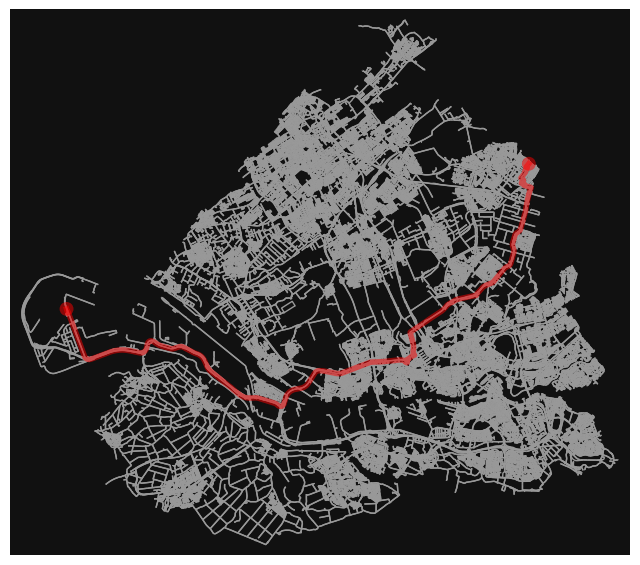

In [19]:
# plot the route of the longest trip
longest_trip = processed_demand.loc[processed_demand["dist"].idxmax(), ["origin_id", "destination_id"]]
origin = longest_trip['origin_id']
destination = longest_trip['destination_id']
print('Origin: {}, destination: {}'.format(origin, destination))
route = nx.shortest_path(graphs["drive"], origin, destination, weight='length')
fig, ax = ox.plot_graph_route(graphs['drive'], route, node_size=0)

In [20]:
processed_demand['dist'].describe()

count    327231.000000
mean       9706.670898
std        7651.520996
min         825.083984
25%        3861.226562
50%        7209.182129
75%       13448.551758
max       62091.296875
Name: dist, dtype: float64

In [21]:
# Remove request with infinite travel time (should already be removed in network generation process, i.e. only accessible nodes should be possible as origin/destination)
# processed_demand = processed_demand.loc[processed_demand['dist'] != np.inf]

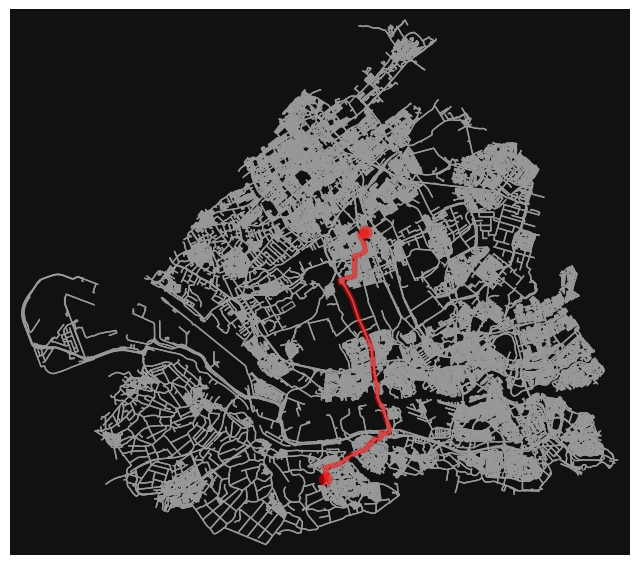

In [22]:
origin = 32143
dest = 2783	
route = nx.shortest_path(graphs['drive'], origin, dest, weight='length')
fig, ax = ox.plot_graph_route(graphs['drive'], route, node_size=0)

In [ ]:
processed_demand.loc[processed_demand['origin_id'] == 44224]

,pax_id,purpose,activity_mode_model,origin_wgs84,dest_wgs84,eucl_dist,treq,origin_id,destination_id,ttrav,dist,origin_id_bike,destination_id_bike,ttrav_bike,dist_bike
202,1636,work,ebike,"(52.103542358888504, 4.320106549911457)","(52.102289896923935, 4.276122387874468)",3016.867125,2025-04-01 08:42:03,44224,44157,390.550659,4744.381836,32143,49789,799.31178,4440.621
222,1709,work,bike,"(52.103439533742424, 4.319391254460202)","(52.07377985602253, 4.308225136909597)",3387.598863,2025-04-01 08:56:04,44224,40408,405.220367,4788.863770,32143,29515,861.99552,4788.864
241,1823,work,bike,"(52.10350077693535, 4.31998141728455)","(52.08230844524256, 4.29535296795751)",2899.755298,2025-04-01 07:30:11,44224,41916,315.928406,3900.559082,32143,30649,697.39578,3874.421
270,1981,work,bike,"(52.1033786576718, 4.319461929241612)","(52.042696243865606, 4.245088154732324)",8460.953061,2025-04-01 09:03:51,44224,60916,858.500854,10682.714844,32143,57183,1888.95996,10494.222


In [27]:
trips.loc[trips['eucledian_dist'] > 30000]

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y,eucledian_dist
620,1293921,3944,social,car,9,26,81541.453125,457413.03125,69341.000000,427511.00000,32295.240041
2624,4699897,14328,work,car,7,48,79786.406250,458809.00000,83231.859375,428654.56250,30350.638349
4142,7477401,22796,work,car,7,30,79180.078125,458494.75000,96319.273438,432722.65625,30950.813111
4346,7817537,23833,work,car,8,17,79017.179688,458567.81250,99103.406250,435951.00000,30248.581871
4388,7896801,24075,othdiscr,car,7,45,78838.867188,458399.31250,94758.812500,429381.56250,33097.952713
...,...,...,...,...,...,...,...,...,...,...,...
495514,839617009,2559807,work,pt,7,35,68883.500000,444588.00000,100819.000000,431685.00000,34443.628863
496167,840753201,2563271,work,car,7,35,68819.625000,445600.84375,98566.484375,436263.59375,31177.874851
496196,840802401,2563421,work,car,8,2,68700.796875,445646.84375,97835.203125,429709.15625,33208.786644
496221,840840449,2563537,work,car,7,59,68788.835938,445496.18750,98748.976562,431506.18750,33065.542885


In [ ]:
# Script to convert requests into georequests which can be used to generate PT itineraries with OpenTripPlanner (query_PT repo)
georequests = pd.DataFrame(index=processed_demand.index)
georequests['pax_id'] = processed_demand['pax_id'].copy()
georequests['treq'] = processed_demand['treq'].copy()
georequests['origin_x'] = processed_demand['origin_wgs84'].apply(lambda row: row[1])
georequests['origin_y'] = processed_demand['origin_wgs84'].apply(lambda row: row[0])
georequests['destination_x'] = processed_demand['dest_wgs84'].apply(lambda row: row[1])
georequests['destination_y'] = processed_demand['dest_wgs84'].apply(lambda row: row[0])
georequests.to_csv(os.path.join(output_path,'georequests.csv'), index=False)

In [30]:
georequests

,treq,origin_x,origin_y,destination_x,destination_y
0,2025-04-01 09:22:20,4.326728,52.106919,4.402333,52.097573
1,2025-04-01 08:39:47,4.326902,52.106785,4.304857,52.079210
2,2025-04-01 09:05:06,4.326424,52.107151,4.317242,52.079816
3,2025-04-01 08:49:11,4.327622,52.105930,4.342734,52.079674
4,2025-04-01 07:41:37,4.326424,52.107151,4.354365,52.040562
...,...,...,...,...,...
496434,2025-04-01 07:40:18,4.129873,51.977360,4.146292,51.969100
496435,2025-04-01 08:27:34,4.135911,51.992144,4.251049,51.974619
496437,2025-04-01 07:51:58,4.131582,51.989639,4.453680,52.095584
496438,2025-04-01 08:40:04,4.135237,51.989835,4.351787,51.994168
